Generating TPC-H data (SF=0.1)...
TPC-H ready.

EXPERIMENT 3: Cache Efficiency

[3.1] Sequential Scan
Time       : 0.0032s
Throughput : 2880.76 MB/s

[3.2] Random Access (Join + Random Filter)
Time       : 0.0293s
Throughput : 1708.36 MB/s

[3.3] Hash Aggregation
Time       : 0.0609s
Throughput : 225.64 MB/s


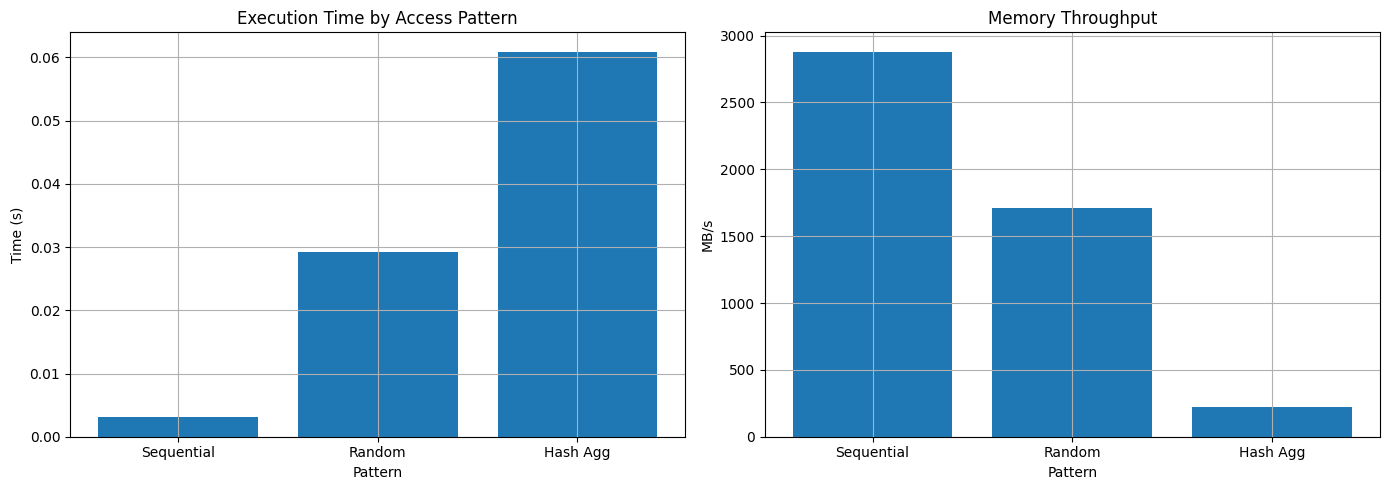

,access_pattern,execution_time,throughput_mb_s
0,Sequential,0.003181,2880.764863
1,Random,0.029268,1708.362088
2,Hash Agg,0.060919,225.643183


In [1]:
"""
Experiment 3: Cache Efficiency & Memory Access Patterns (TPC-H)
"""

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


# -----------------------------
# 1. Initialize TPC-H
# -----------------------------
def init_tpch(scale_factor=0.1):
    con = duckdb.connect(':memory:')
    
    print(f"Generating TPC-H data (SF={scale_factor})...")
    con.execute("INSTALL tpch")
    con.execute("LOAD tpch")
    con.execute(f"CALL dbgen(sf={scale_factor})")
    
    print("TPC-H ready.\n")
    return con


# -----------------------------
# 2. Experiment 3
# -----------------------------
def experiment_3(con):

    print("="*80)
    print("EXPERIMENT 3: Cache Efficiency")
    print("="*80)

    results = {
        "access_pattern": [],
        "execution_time": [],
        "throughput_mb_s": []
    }

    # -------------------------
    # 3.1 Sequential scan (cache-friendly)
    # -------------------------
    print("\n[3.1] Sequential Scan")

    query_seq = """
        SELECT SUM(l_quantity), AVG(l_extendedprice)
        FROM lineitem
    """

    start = time.perf_counter()
    con.execute(query_seq).fetchone()
    seq_time = time.perf_counter() - start

    row_count = con.execute("SELECT COUNT(*) FROM lineitem").fetchone()[0]
    data_size_mb = (row_count * (8 + 8)) / (1024 * 1024)

    throughput_seq = data_size_mb / seq_time

    results["access_pattern"].append("Sequential")
    results["execution_time"].append(seq_time)
    results["throughput_mb_s"].append(throughput_seq)

    print(f"Time       : {seq_time:.4f}s")
    print(f"Throughput : {throughput_seq:.2f} MB/s")


    # -------------------------
    # 3.2 Random access (cache-unfriendly)
    # -------------------------
    print("\n[3.2] Random Access (Join + Random Filter)")

    query_random = """
        SELECT o.o_orderkey, l.l_quantity
        FROM orders o
        JOIN lineitem l ON o.o_orderkey = l.l_orderkey
        WHERE o.o_orderkey IN (
            SELECT o_orderkey
            FROM orders
            WHERE random() < 0.01
            LIMIT 10000
        )
    """

    start = time.perf_counter()
    con.execute(query_random).fetchall()
    rand_time = time.perf_counter() - start

    # Rough estimate (random access is harder to quantify exactly)
    data_size_mb = 50  
    throughput_rand = data_size_mb / rand_time

    results["access_pattern"].append("Random")
    results["execution_time"].append(rand_time)
    results["throughput_mb_s"].append(throughput_rand)

    print(f"Time       : {rand_time:.4f}s")
    print(f"Throughput : {throughput_rand:.2f} MB/s")


    # -------------------------
    # 3.3 Hash aggregation (cache-sensitive)
    # -------------------------
    print("\n[3.3] Hash Aggregation")

    query_agg = """
        SELECT 
            l_partkey,
            COUNT(*),
            SUM(l_quantity),
            AVG(l_extendedprice)
        FROM lineitem
        GROUP BY l_partkey
    """

    start = time.perf_counter()
    con.execute(query_agg).fetchall()
    agg_time = time.perf_counter() - start

    data_size_mb = (row_count * 24) / (1024 * 1024)
    throughput_agg = data_size_mb / agg_time

    results["access_pattern"].append("Hash Agg")
    results["execution_time"].append(agg_time)
    results["throughput_mb_s"].append(throughput_agg)

    print(f"Time       : {agg_time:.4f}s")
    print(f"Throughput : {throughput_agg:.2f} MB/s")

    return results


# -----------------------------
# 3. Plot (Notebook)
# -----------------------------
def plot_experiment_3(results):

    df = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Execution time
    axes[0].bar(df["access_pattern"], df["execution_time"])
    axes[0].set_title("Execution Time by Access Pattern")
    axes[0].set_xlabel("Pattern")
    axes[0].set_ylabel("Time (s)")
    axes[0].grid()

    # Throughput
    axes[1].bar(df["access_pattern"], df["throughput_mb_s"])
    axes[1].set_title("Memory Throughput")
    axes[1].set_xlabel("Pattern")
    axes[1].set_ylabel("MB/s")
    axes[1].grid()

    plt.tight_layout()
    plt.show()


# -----------------------------
# 4. RUN (Notebook)
# -----------------------------
con = init_tpch(scale_factor=0.1)

results = experiment_3(con)

plot_experiment_3(results)

pd.DataFrame(results)